# K02 — Lake Baringo, year by year

K01 §5 compared **one** Baringo tile in **two** years and found the shoreline
had moved. This notebook does the whole lake, every year: all nine tiles that
cover it, for each year 2017–2025.

The questions, in order:

1. How big was the lake each year, and do those numbers agree with published
   estimates?
2. Where did the shoreline move, and in which year?
3. How much land went under water, and how much came back out?
4. How much of that should we trust?

This is the first real step of use case **W1** (the Rift Valley lakes): drawing
the water edge for every year, so land lost can be measured and dated.

**Downloads:** 9 tiles × 9 years = 81 tile-years, about **13 GB** on a cold
cache (~163 MB each). Later runs read the cache, and the water masks are also
saved to `outputs/`, so a rerun takes seconds.

In [1]:
# ---------------------------------------------------------------------------
# SETUP
# ---------------------------------------------------------------------------
import sys
from pathlib import Path

import numpy as np                    # array maths
import pandas as pd                   # tables
import geopandas as gpd               # borders
import matplotlib.pyplot as plt       # every figure below
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.patches import Patch
from rasterio.transform import from_origin
from rasterio.warp import Resampling, reproject, transform_bounds
from scipy import ndimage             # connected components: "which water is the lake"

# Jupyter may start in the repo root or in experiments/. Locate src/kenya.py
repo_root = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "src" / "kenya.py").is_file()),
    None,
)
if repo_root is None:
    raise RuntimeError("Could not locate the repository root containing src/kenya.py")
sys.path.insert(0, str(repo_root / "src"))

import kenya as K           # shared helpers for this series — see src/kenya.py

gt = K.client()
YEARS = K.DEEP_YEARS
print("years:", YEARS)

years: [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]


## 1. The tiles that cover the lake

Lake Baringo sits at about 36.06°E, 0.63°N. Its shoreline stays well inside a
3 × 3 block of tiles, from 35.9 to 36.2°E and 0.5 to 0.8°N: 33 × 33 km, with
room for the lake to grow in any direction. §4 checks that the lake never
touches the edge of the block.

In [2]:
# ---------------------------------------------------------------------------
# THE 3 x 3 BLOCK — all in Kenya, all nine years?
# ---------------------------------------------------------------------------
LONS = (35.95, 36.05, 36.15)
LATS = (0.75, 0.65, 0.55)             # north to south, so tables read like a map
TILES = [(lon, lat) for lat in LATS for lon in LONS]

cat = K.catalogue()
block = cat.set_index(["lon", "lat"]).loc[TILES, ["province", "n_years"]]
print(block.to_string())
print(f"\n{len(block)} tiles, {int(block.n_years.sum())} tile-years "
      f"(~{block.n_years.sum() * 0.163:.0f} GB on a cold cache)")
print("\nlake on satellite imagery:", K.gmaps(36.06, 0.63))

               province  n_years
lon   lat                       
35.95 0.75  Rift Valley        9
36.05 0.75  Rift Valley        9
36.15 0.75  Rift Valley        9
35.95 0.65  Rift Valley        9
36.05 0.65  Rift Valley        9
36.15 0.65  Rift Valley        9
35.95 0.55  Rift Valley        9
36.05 0.55  Rift Valley        9
36.15 0.55  Rift Valley        9

9 tiles, 81 tile-years (~13 GB on a cold cache)

lake on satellite imagery: https://www.google.com/maps/@0.63000,36.06000,15z/data=!3m1!1e3


Nine tiles, all in Rift Valley province, all with nine years. So the whole
lake has a complete record, 81 tile-years with nothing missing.

## 2. How a pixel is called "water"

The same test as K01 §4. Two reference fingerprints are built from tiles whose
identity is not in doubt, **open Lake Victoria** (water) and **central
Nairobi** (land), and each pixel is labelled by whichever it resembles more.
Both references come from 2024 and are used for every year, so the only thing
that changes from year to year is the ground itself.

K01 showed this split is real signal: water and land sit at cosine 0.42, and it
draws a clean shoreline on Lake Turkana. Both reference tiles are already in
the cache from K01.

In [3]:
# ---------------------------------------------------------------------------
# THE TWO REFERENCES (identical to K01 §4)
# ---------------------------------------------------------------------------
water_ref = K.reference(gt, *K.WATER_REF_TILE)
land_ref  = K.reference(gt, *K.LAND_REF_TILE)
print(f"water reference vs land reference, cosine: {float(water_ref @ land_ref):.3f}")

water reference vs land reference, cosine: 0.416


## 3. One map per year

Each tile arrives in its own map projection. The western column (35.95°E) is in
UTM zone 36, the other two in zone 37, because 36°E is where the zones meet.
So every tile's water mask is copied onto **one shared 10 m grid in UTM zone
37N** (nearest neighbour, no smoothing). On that grid every pixel is exactly
100 m², so area is just a count.

Each grid pixel gets one of three codes: **0** land, **1** water, **255** no
data.

The result is saved to `outputs/k02_baringo_water.npz`. On later runs this cell
reads that file instead of reprocessing 81 tiles. Delete the file to rebuild.

In [4]:
# ---------------------------------------------------------------------------
# BUILD (or load) THE NINE WATER MAPS
# ---------------------------------------------------------------------------
GRID_CRS = "EPSG:32637"
PX_KM2 = 10 * 10 / 1e6                # one 10 m pixel, in km^2

# The block's corners in metres, snapped outward to the 10 m pixel grid.
W, S, E, N = transform_bounds("EPSG:4326", GRID_CRS, 35.9, 0.5, 36.2, 0.8)
W, S = np.floor(W / 10) * 10, np.floor(S / 10) * 10
E, N = np.ceil(E / 10) * 10, np.ceil(N / 10) * 10
GRID = from_origin(W, N, 10, 10)
GH, GW = int((N - S) / 10), int((E - W) / 10)

CACHE = repo_root / "outputs" / "k02_baringo_water.npz"

def build_year(year):
    """One (GH, GW) uint8 map for `year`, plus each tile's own water fraction."""
    mosaic = np.full((GH, GW), 255, np.uint8)
    tile_water = {}
    for lon, lat in TILES:
        emb, crs, transform = K.fetch(gt, lon, lat, year)
        valid = K.valid_mask(emb)
        wet = K.water_mask(emb, water_ref, land_ref)
        tile_water[(lon, lat)] = float(wet.mean())
        codes = np.where(valid, wet, 255).astype(np.uint8)
        reproject(codes, mosaic, src_transform=transform, src_crs=crs,
                  dst_transform=GRID, dst_crs=GRID_CRS,
                  resampling=Resampling.nearest,
                  src_nodata=255, dst_nodata=255, init_dest_nodata=False)
        del emb                       # ~630 MB each; keep memory flat
    return mosaic, tile_water

if CACHE.exists():
    saved = np.load(CACHE, allow_pickle=True)
    maps = saved["maps"]
    tile_water = saved["tile_water"].item()
    print(f"loaded {CACHE.relative_to(repo_root)}")
else:
    maps, tile_water = [], {}
    for year in YEARS:
        mosaic, fractions = build_year(year)
        maps.append(mosaic)
        tile_water[year] = fractions
        print(f"{year}: {np.mean(mosaic == 1):.1%} of the block is water")
    maps = np.stack(maps)
    CACHE.parent.mkdir(exist_ok=True)
    np.savez_compressed(CACHE, maps=maps, tile_water=np.array(tile_water, dtype=object))

print(f"grid: {GH} x {GW} pixels of 10 m, {GH * GW * PX_KM2:,.0f} km^2")
print(f"no-data pixels: {np.mean(maps == 255):.2%} (the thin strip where the grid "
      f"overhangs the tiles)")

loaded outputs/k02_baringo_water.npz
grid: 3323 x 3345 pixels of 10 m, 1,112 km^2
no-data pixels: 0.10% (the thin strip where the grid overhangs the tiles)


**First, a consistency check against K01.** K01 §5 measured the tile
`(36.05, 0.65)` on its own and found **64.5%** water in 2017 and **66.6%** in
2025. The per-tile fractions recorded above should give exactly the same
numbers, because they are the same pixels and the same test.

In [5]:
# ---------------------------------------------------------------------------
# DOES THIS AGREE WITH K01?
# ---------------------------------------------------------------------------
for year in (YEARS[0], YEARS[-1]):
    print(f"tile (36.05, 0.65), {year}: {tile_water[year][(36.05, 0.65)]:.1%} water")

tile (36.05, 0.65), 2017: 64.5% water
tile (36.05, 0.65), 2025: 66.6% water


## 4. How big was the lake each year?

"Water" in the maps includes more than the lake: river channels, small ponds,
and the odd misread pixel. The lake is taken to be the **largest connected
patch of water** each year. Everything else is counted separately, so it is
visible rather than silently included.

In [6]:
# ---------------------------------------------------------------------------
# LAKE AREA PER YEAR
# ---------------------------------------------------------------------------
def the_lake(mosaic):
    """Boolean mask of the largest connected patch of water."""
    labels, _ = ndimage.label(mosaic == 1)
    sizes = np.bincount(labels.ravel())
    sizes[0] = 0                      # label 0 is "not water"
    return labels == sizes.argmax()

lakes = np.stack([the_lake(m) for m in maps])

def touches_edge(mask):
    return bool(mask[0].any() or mask[-1].any() or mask[:, 0].any() or mask[:, -1].any())

area = pd.DataFrame({
    "lake_km2":        lakes.sum((1, 2)) * PX_KM2,
    "other_water_km2": ((maps == 1) & ~lakes).sum((1, 2)) * PX_KM2,
    "touches_edge":    [touches_edge(l) for l in lakes],
}, index=pd.Index(YEARS, name="year"))
area["change_km2"] = area.lake_km2.diff()
print(area.to_string(float_format=lambda v: f"{v:,.1f}"))

lo, hi = area.lake_km2.idxmin(), area.lake_km2.idxmax()
print(f"\nsmallest: {lo} ({area.lake_km2[lo]:.1f} km^2)   "
      f"largest: {hi} ({area.lake_km2[hi]:.1f} km^2)")

      lake_km2  other_water_km2  touches_edge  change_km2
year                                                     
2017     181.3              0.4         False         NaN
2018     184.0              0.8         False         2.7
2019     185.7              0.6         False         1.7
2020     198.0              2.4         False        12.4
2021     219.3              0.9         False        21.3
2022     219.1              1.0         False        -0.2
2023     211.6              0.3         False        -7.5
2024     211.7              1.0         False         0.2
2025     223.0              0.8         False        11.3

smallest: 2017 (181.3 km^2)   largest: 2025 (223.0 km^2)


**How does that compare with published estimates?** Two independent figures
exist for 2020, and they disagree with each other:

- **~209 km²** (20,931 ha): a Landsat/Sentinel-1 classification checked with
  GPS ground points
  ([East African Journal of Environment and Natural Resources](https://journals.eanso.org/index.php/eajenr/article/view/5277)).
- **268 km²**: a 2021 Kenyan Government report, as cited on
  [Wikipedia](https://en.wikipedia.org/wiki/Lake_Baringo).

Both are drawn on the chart below.

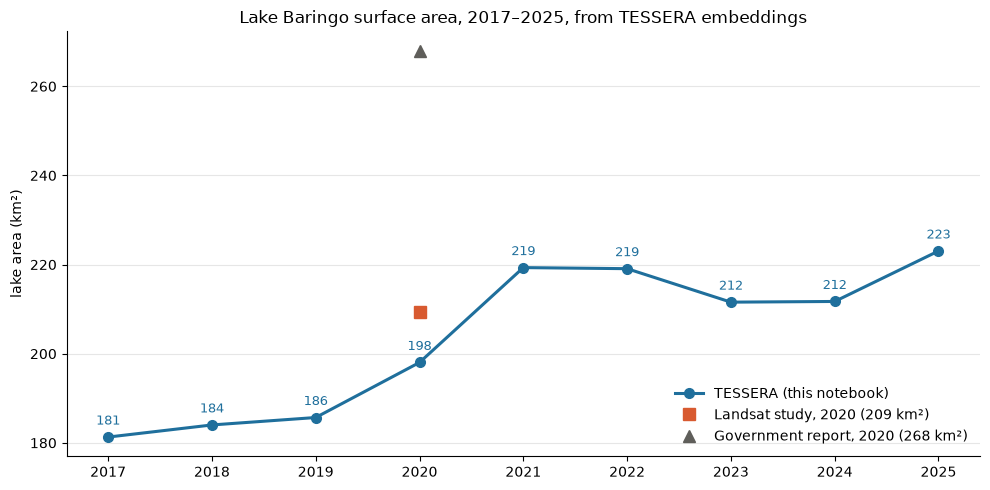

In [7]:
# ---------------------------------------------------------------------------
# THE CHART
# ---------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(area.index, area.lake_km2, "o-", color="#1f6f9c", lw=2.2, ms=7,
        label="TESSERA (this notebook)")
for year, km2 in area.lake_km2.items():
    ax.annotate(f"{km2:.0f}", (year, km2), textcoords="offset points",
                xytext=(0, 9), ha="center", fontsize=9, color="#1f6f9c")

ax.plot([2020], [209.3], "s", color="#D85A30", ms=9,
        label="Landsat study, 2020 (209 km²)")
ax.plot([2020], [268], "^", color="#5F5E5A", ms=9,
        label="Government report, 2020 (268 km²)")

ax.set_xticks(YEARS)
ax.set_ylabel("lake area (km²)")
ax.set_title("Lake Baringo surface area, 2017–2025, from TESSERA embeddings", fontsize=12)
ax.grid(axis="y", color="0.9"); ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
ax.legend(frameon=False, loc="lower right")
plt.tight_layout(); plt.show()


The lake grew by **42 km² (+23%)**, from 181 km² in 2017 to 223 km² in 2025. The
growth was not steady: small until 2019 (+4 km²), then **+34 km² in 2020–2021**,
a dip of 7.5 km² in 2023, and a new high in 2025.

Against the published 2020 figures, 198 km² is **5% below the Landsat study**
(209 km²) and well below the government report (268 km²). Those two disagree
with each other by 28%, so the absolute area depends heavily on method. One
likely reason this estimate is lower: the test has only two classes, so
shallow, vegetated water at the edges can be called land. The *size and timing*
of the rise are the more trustworthy part.


## 5. Where did the shoreline move?

One small map per year, drawn on the same grid, so any change in shape is
directly comparable panel to panel.

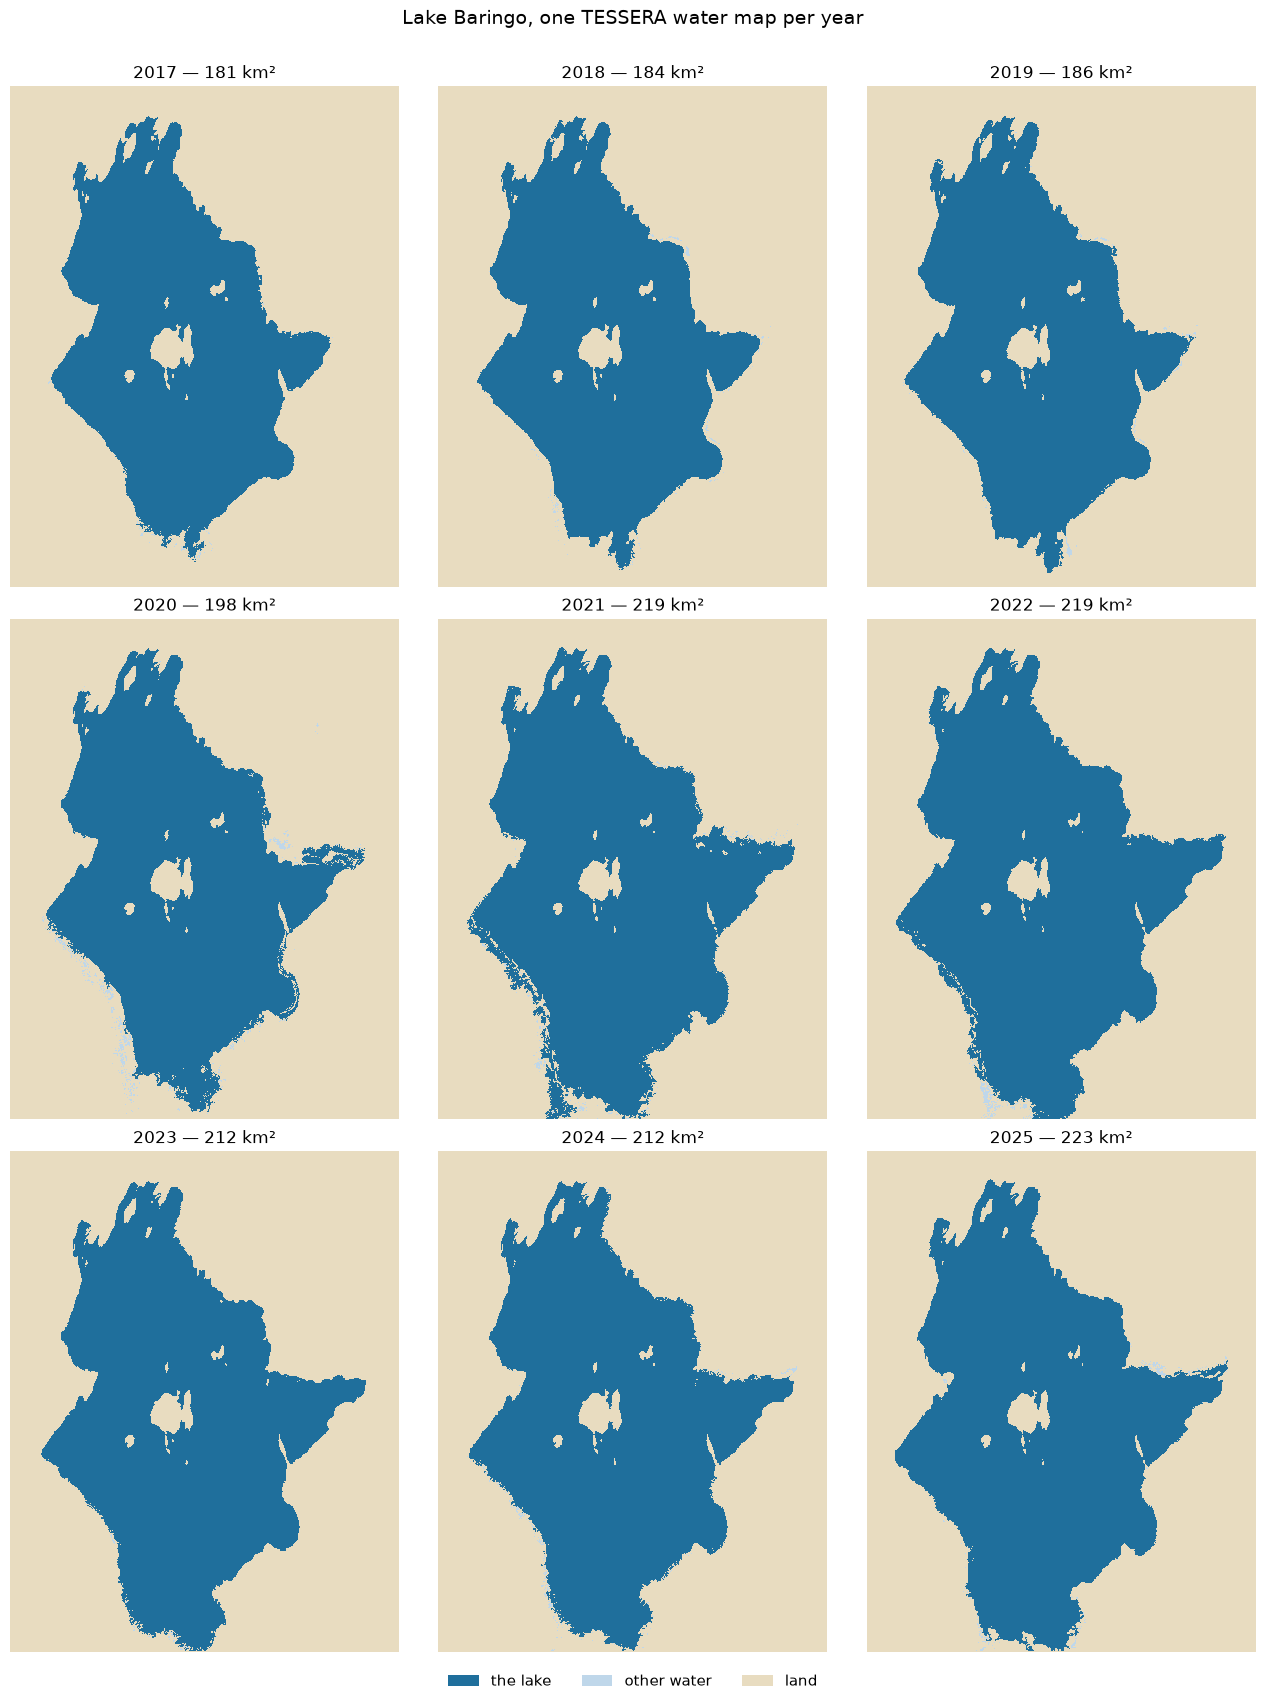

In [8]:
# ---------------------------------------------------------------------------
# NINE LAKES, SIDE BY SIDE
# ---------------------------------------------------------------------------
# Crop to the lake's largest extent, plus a margin, so the panels are not
# mostly empty land.
ever = lakes.any(0)
rows, cols = np.nonzero(ever)
pad = 150                             # 1.5 km
r0, r1 = max(rows.min() - pad, 0), min(rows.max() + pad, GH)
c0, c1 = max(cols.min() - pad, 0), min(cols.max() + pad, GW)
crop = (slice(r0, r1), slice(c0, c1))

cmap3 = ListedColormap(["#e8dcc0", "#1f6f9c", "#bfd7ea"])   # land, lake, other water
fig, axes = plt.subplots(3, 3, figsize=(13, 17))
for ax, year, m, lake in zip(axes.flat, YEARS, maps, lakes):
    img = np.where(lake, 1, np.where(m == 1, 2, 0))[crop]
    ax.imshow(img, cmap=cmap3, vmin=0, vmax=2, interpolation="nearest")
    ax.set_title(f"{year} — {lake.sum() * PX_KM2:.0f} km²", fontsize=12)
    ax.axis("off")
fig.legend(handles=[Patch(fc="#1f6f9c", label="the lake"),
                    Patch(fc="#bfd7ea", label="other water"),
                    Patch(fc="#e8dcc0", label="land")],
           loc="lower center", ncol=3, frameon=False, fontsize=11)
fig.suptitle("Lake Baringo, one TESSERA water map per year", fontsize=14, y=0.995)
plt.tight_layout(rect=(0, 0.02, 1, 0.99)); plt.show()

The small multiples show *that* the lake changed. The map below shows *when*:
every pixel that was land in 2017 and lake in a later year is coloured by the
**first year it was under water**.

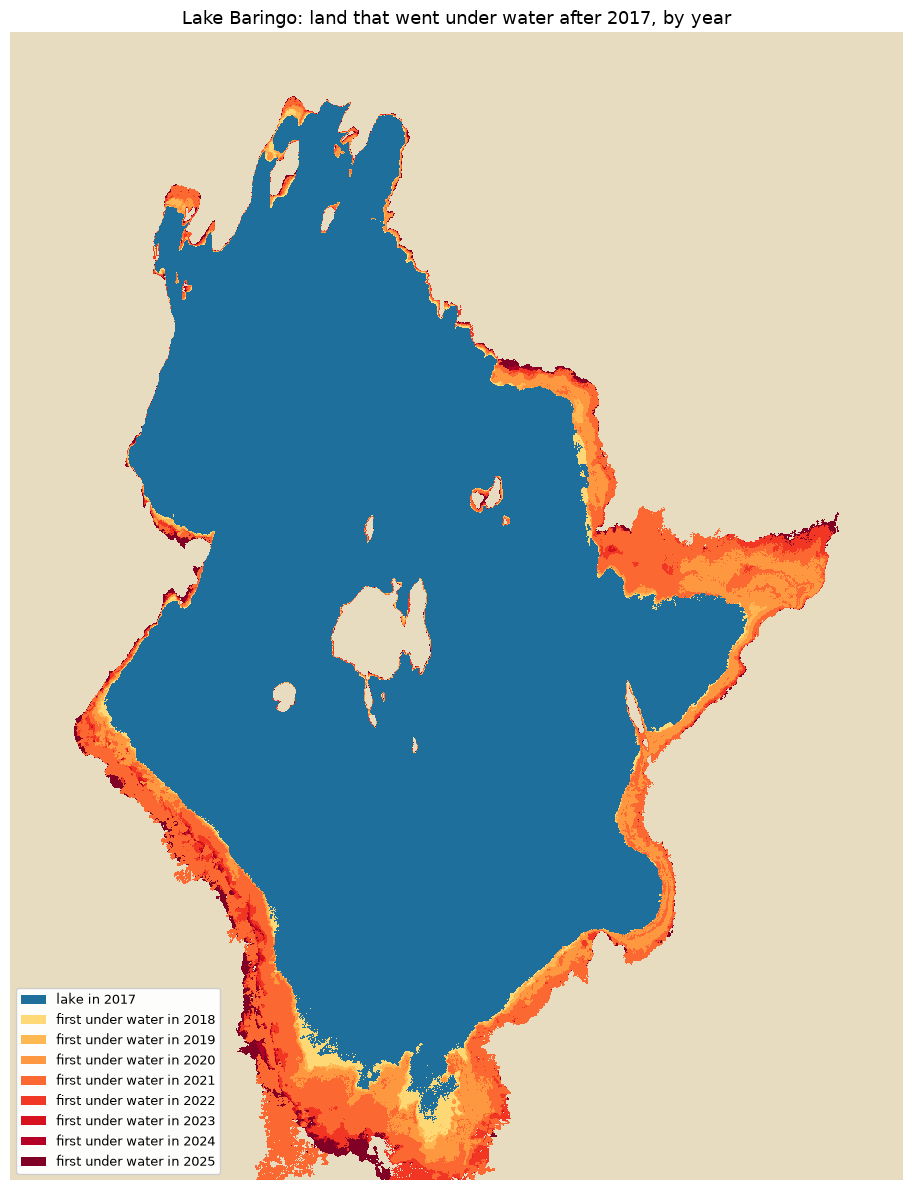

In [9]:
# ---------------------------------------------------------------------------
# WHEN DID EACH PIXEL FIRST GO UNDER WATER?
# ---------------------------------------------------------------------------
base = lakes[0]                                   # the 2017 lake
wet_later = lakes[1:] & ~base                     # lake in year t, land in 2017
first = np.where(wet_later.any(0), np.argmax(wet_later, 0) + 1, 0)   # index into YEARS

later_years = YEARS[1:]
colours = plt.cm.YlOrRd(np.linspace(0.25, 1.0, len(later_years)))
cmap_first = ListedColormap(["#e8dcc0", "#1f6f9c", *colours])
img = np.where(base, 1, np.where(first > 0, first + 1, 0))[crop]

fig, ax = plt.subplots(figsize=(10, 12))
ax.imshow(img, cmap=cmap_first, norm=BoundaryNorm(np.arange(-0.5, len(later_years) + 2), cmap_first.N),
          interpolation="nearest")
ax.axis("off")
ax.legend(handles=[Patch(fc="#1f6f9c", label=f"lake in {YEARS[0]}")] +
                  [Patch(fc=c, label=f"first under water in {y}") for y, c in zip(later_years, colours)],
          loc="lower left", fontsize=9, framealpha=0.95)
ax.set_title(f"Lake Baringo: land that went under water after {YEARS[0]}, by year", fontsize=13)
plt.tight_layout(); plt.show()


The new water sits in **continuous bands that step outward year by year**, not
as scattered pixels, which is what a real shoreline moving should look like.
The widest bands are on the southern and eastern shores, where the same rise in
water level covers the most ground.


## 6. How much land went under water?

"First under water" is not the same as "lost". A pixel can be flooded in a wet
year and dry out again. So three numbers are worth separating:

- **flooded and stayed flooded:** land in 2017, lake in every year from its
  first flooding through 2025;
- **flooded, then came back:** land in 2017, lake in some year, land again by
  2025;
- **lake that became land:** lake in 2017, land in 2025 (the lake retreating).

In [10]:
# ---------------------------------------------------------------------------
# LAND LOST, LAND RETURNED
# ---------------------------------------------------------------------------
idx = np.arange(len(YEARS))[:, None, None]
after_first = idx >= first[None]                  # years from first flooding onward
stayed = (first > 0) & np.all(lakes | ~after_first, axis=0)
came_back = (first > 0) & ~stayed
retreated = base & ~lakes[-1]

summary = pd.Series({
    f"land in {YEARS[0]}, under water at least once since":  (first > 0).sum(),
    "   ...and stayed under water through 2025":              stayed.sum(),
    "   ...but dry again by 2025":                            came_back.sum(),
    f"lake in {YEARS[0]}, land in {YEARS[-1]}":               retreated.sum(),
}) * PX_KM2
print(summary.to_string(float_format=lambda v: f"{v:7.1f} km^2"))
print(f"\nnet change {YEARS[0]} -> {YEARS[-1]}: "
      f"{(lakes[-1].sum() - base.sum()) * PX_KM2:+.1f} km^2")

by_year = pd.Series([(first == i).sum() * PX_KM2 for i in range(1, len(YEARS))],
                    index=pd.Index(later_years, name="first under water"), name="km^2")
print("\n" + by_year.to_string(float_format=lambda v: f"{v:6.1f}"))

land in 2017, under water at least once since      45.9 km^2
   ...and stayed under water through 2025          31.3 km^2
   ...but dry again by 2025                        14.6 km^2
lake in 2017, land in 2025                          0.0 km^2

net change 2017 -> 2025: +41.7 km^2

first under water
2018      3.0
2019      1.7
2020     12.1
2021     21.3
2022      4.4
2023      0.4
2024      0.2
2025      2.8



**46 km² of land** has been under water at least once since 2017. **31 km²** of
it went under and stayed under through 2025; 15 km² went under and dried out
again. No part of the 2017 lake had turned into land by 2025, so the lake only
moved outward.

The flooding is concentrated in time: **2020 (12 km²) and 2021 (21 km²)**
together account for about 73% of all newly flooded land.


## 7. How much of this should we trust?

The water/land test is applied to each year independently, with no smoothing
over time. If it were noisy, pixels would **flicker**: water, land, water, land
from one year to the next, with no real change on the ground. Real shoreline
change should look like a few clean switches.

So count, for every pixel that was lake at least once, how many times its label
switched across the nine years.

In [11]:
# ---------------------------------------------------------------------------
# FLICKER: how often does a pixel switch between lake and land?
# ---------------------------------------------------------------------------
touched = lakes.any(0) & ~lakes.all(0)            # lake in some years, not all
switches = np.abs(np.diff(lakes.astype(np.int8), axis=0)).sum(0)[touched]

counts = pd.Series(switches).value_counts().sort_index()
share = counts / counts.sum()
print(f"pixels that were lake in some years but not all: {touched.sum() * PX_KM2:.1f} km^2\n")
print("switches   area (km^2)   share")
for n, c in counts.items():
    print(f"{n:>8}   {c * PX_KM2:>11.1f}   {share[n]:>5.1%}")
print(f"\nlake in every one of the nine years: {lakes.all(0).sum() * PX_KM2:.1f} km^2")

# Which sequences do the multi-switch pixels follow? One letter per year,
# W = lake, . = land. Random flicker would spread over many patterns.
from collections import Counter
multi = np.argwhere((np.abs(np.diff(lakes.astype(np.int8), axis=0)).sum(0) >= 2) & touched)
patterns = Counter("".join("W" if lakes[t, r, c] else "." for t in range(len(YEARS)))
                   for r, c in multi)
print("\nmost common sequences among pixels that switched 2+ times "
      f"({' '.join(str(y)[2:] for y in YEARS)}):")
for pat, n in patterns.most_common(5):
    print(f"  {' '.join(' ' + ch for ch in pat)}   {n * PX_KM2:.1f} km^2")

pixels that were lake in some years but not all: 46.4 km^2

switches   area (km^2)   share
       1          31.3   67.4%
       2           4.6    9.9%
       3          10.4   22.5%
       4           0.0    0.0%
       5           0.1    0.1%
       6           0.0    0.0%
       7           0.0    0.0%
       8           0.0    0.0%

lake in every one of the nine years: 180.8 km^2



most common sequences among pixels that switched 2+ times (17 18 19 20 21 22 23 24 25):
   .  .  .  .  W  W  .  .  W   3.5 km^2
   .  .  .  .  W  .  .  .  .   2.4 km^2
   .  .  .  .  W  .  .  .  W   2.0 km^2
   .  .  .  .  W  W  .  W  W   1.4 km^2
   .  .  .  .  .  W  .  .  W   1.3 km^2



Two-thirds of the changing area switched **exactly once**: land to lake, and it
stayed. The rest follow a small family of sequences with one shape, rather
than random flicker: **first under water in 2021 or 2022, dry in 2023**, and
mostly wet again by 2025. That is the same dip and recovery as the area chart. Pixels switching five or
more times, the signature of a noisy test, cover about 0.1 km².



## 8. What this notebook establishes

1. **Lake Baringo has a complete nine-year record.** 9 tiles × 9 years, nothing
   missing, and the one tile K01 measured gives identical numbers here (64.5%
   water in 2017, 66.6% in 2025).

2. **The lake grew by 42 km² (+23%) between 2017 and 2025**, from 181 to
   223 km², and most of that happened in two years: **+34 km² in 2020–2021**.
   It dipped by 7.5 km² in 2023 and reached its largest extent in 2025.

3. **The 2020 figure (198 km²) is within 5% of an independent Landsat study
   (209 km²).** It is well below the government's 268 km², but the two
   published figures disagree with each other by 28%, so the exact area depends
   on the method. The *size and timing* of the rise are more trustworthy than
   the absolute number.

4. **46 km² of land went under water at least once; 31 km² went under and
   stayed under.** Nothing that was lake in 2017 had become land by 2025. About
   73% of all newly flooded land first went under in 2020 or 2021.

5. **The result is stable, not noisy.** Two-thirds of the changing area switched
   exactly once. The rest share one shape (under water from 2021 or 2022, dry
   in 2023, mostly wet again by 2025), and pixels that flicker five or more
   times cover only ~0.1 km².

**Limits, stated plainly:**

- **One map per year.** Each embedding summarises a whole year, so this is an
  annual extent, not the seasonal peak after the rains.
- **Two classes only.** Every pixel is called water or land. Swamp, flooded
  grass and wet mud go to whichever they resemble more, which is a likely reason
  this estimate sits below the others.
- **The record starts in 2017.** Baringo was already rising from 2010, so the
  first, large phase of the rise is not in this data.
- **"Land" here means "not open water".** It does not say the flooded land was
  farmland, homes or grazing. Finding out what went under is the second half of
  use case W1, and needs other data (settlement or farm maps) to do honestly.
- **The 2023 dip coincides with the 2020–2023 drought in the Horn of Africa.**
  That fits, but this notebook does not prove the cause.
